In [28]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
# load the pharmacy sales dataset
df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset (1).csv")

# check shape of data
print("Rows and Columns:", df.shape)

# check first 5 rows
df.head()

Rows and Columns: (177990, 14)


,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0


In [30]:
# list of numeric columns
numeric_cols = ["units_sold", "unit_price", "stock_level", "expiry_days_remaining", "covid_flag"]

# print numeric columns
print(numeric_cols)

['units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining', 'covid_flag']


In [31]:
# convert categorical columns into numeric codes so we can also check
# their correlation with numeric columns (label encoding)
df["region_code"] = df["region"].astype("category").cat.codes
df["category_code"] = df["category"].astype("category").cat.codes
df["medicine_code"] = df["medicine"].astype("category").cat.codes
df["age_group_code"] = df["age_group"].astype("category").cat.codes

# final list of columns used for correlation analysis
corr_cols = numeric_cols + ["region_code", "category_code", "medicine_code", "age_group_code"]

print(corr_cols)

['units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining', 'covid_flag', 'region_code', 'category_code', 'medicine_code', 'age_group_code']


In [32]:
# calculate Pearson correlation (measures linear relationship)
pearson_corr = df[corr_cols].corr(method="pearson")

print(pearson_corr)

                       units_sold  unit_price  stock_level  \
units_sold               1.000000    0.000562    -0.937466   
unit_price               0.000562    1.000000    -0.000594   
stock_level             -0.937466   -0.000594     1.000000   
expiry_days_remaining    0.000181    0.000959    -0.001409   
covid_flag               0.312774    0.002173    -0.303465   
region_code              0.003152   -0.002401    -0.002497   
category_code           -0.000151   -0.003464     0.000195   
medicine_code            0.003215   -0.003312    -0.003780   
age_group_code           0.001661    0.000277    -0.002237   

                       expiry_days_remaining    covid_flag   region_code  \
units_sold                          0.000181  3.127743e-01  3.151971e-03   
unit_price                          0.000959  2.172786e-03 -2.401278e-03   
stock_level                        -0.001409 -3.034647e-01 -2.496984e-03   
expiry_days_remaining               1.000000 -7.785094e-04 -1.196735e-03   

In [33]:
# calculate Spearman correlation (measures monotonic/non-linear relationship using rank)
spearman_corr = df[corr_cols].corr(method="spearman")

print(spearman_corr)

                       units_sold  unit_price  stock_level  \
units_sold               1.000000   -0.002701    -0.811389   
unit_price              -0.002701    1.000000     0.002464   
stock_level             -0.811389    0.002464     1.000000   
expiry_days_remaining    0.000654    0.000962    -0.002952   
covid_flag               0.486021    0.002167    -0.410529   
region_code              0.001703   -0.002407     0.000039   
category_code           -0.001199   -0.003468     0.000733   
medicine_code           -0.000772   -0.003310    -0.000770   
age_group_code           0.003446    0.000274    -0.003640   

                       expiry_days_remaining    covid_flag   region_code  \
units_sold                          0.000654  4.860206e-01  1.702501e-03   
unit_price                          0.000962  2.167063e-03 -2.407348e-03   
stock_level                        -0.002952 -4.105290e-01  3.944146e-05   
expiry_days_remaining               1.000000 -7.798684e-04 -1.195104e-03   

In [34]:
# calculate Kendall correlation (measures ordinal association using rank pairs)
kendall_corr = df[corr_cols].corr(method="kendall")

print(kendall_corr)

                       units_sold  unit_price  stock_level  \
units_sold               1.000000   -0.001799    -0.619324   
unit_price              -0.001799    1.000000     0.001644   
stock_level             -0.619324    0.001644     1.000000   
expiry_days_remaining    0.000439    0.000643    -0.001972   
covid_flag               0.397168    0.001769    -0.335415   
region_code              0.001205   -0.001703     0.000025   
category_code           -0.000876   -0.002534     0.000532   
medicine_code           -0.000540   -0.002313    -0.000536   
age_group_code           0.002522    0.000199    -0.002666   

                       expiry_days_remaining    covid_flag   region_code  \
units_sold                          0.000439  3.971677e-01  1.205385e-03   
unit_price                          0.000643  1.769497e-03 -1.702526e-03   
stock_level                        -0.001972 -3.354150e-01  2.501841e-05   
expiry_days_remaining               1.000000 -6.372223e-04 -8.456932e-04   

In [35]:
# function to plot correlation heatmap using matplotlib only
def plot_heatmap(corr_matrix, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)   # draw heatmap
    plt.colorbar()                                              # add color scale

    # set axis labels
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

    # add correlation value text on each cell
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            value = round(corr_matrix.iloc[i, j], 2)
            plt.text(j, i, value, ha="center", va="center", color="black", fontsize=8)

    plt.title(title)
    plt.tight_layout()
    plt.show()

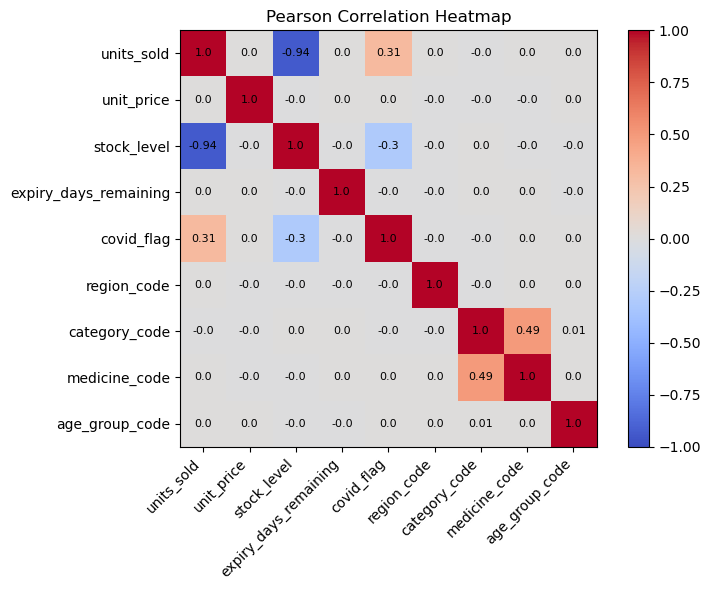

In [36]:
# plot Pearson correlation heatmap
plot_heatmap(pearson_corr, "Pearson Correlation Heatmap")

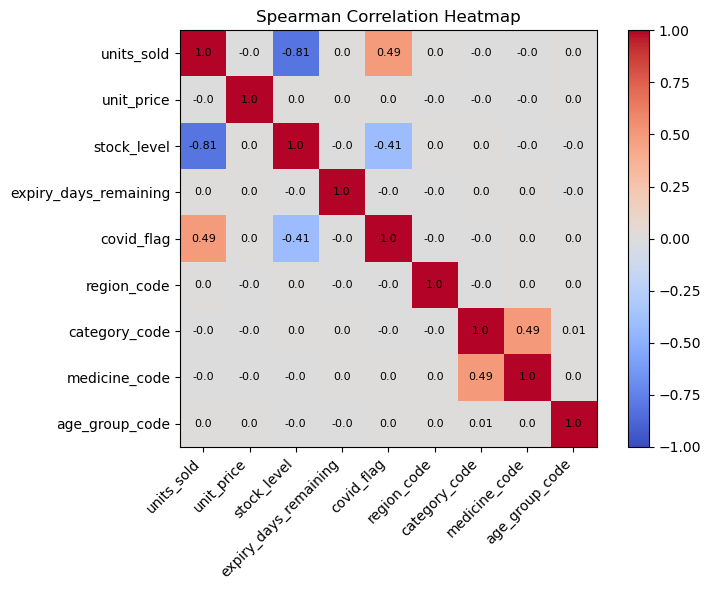

In [37]:
# plot Spearman correlation heatmap
plot_heatmap(spearman_corr, "Spearman Correlation Heatmap")

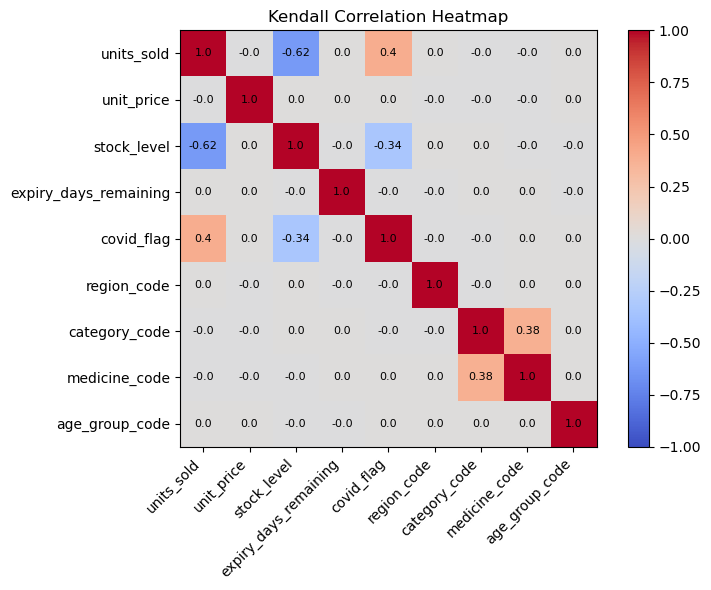

In [38]:
# plot Kendall correlation heatmap
plot_heatmap(kendall_corr, "Kendall Correlation Heatmap")

In [39]:

# Interpretation of Pearson correlation:
# Pearson only measures LINEAR relationship between two variables.
# Value close to +1 means strong positive linear relation.
# Value close to -1 means strong negative linear relation.
# Value close to 0 means no linear relation (but non-linear relation may exist).
# It is sensitive to outliers, since it uses actual data values.


In [40]:

# Interpretation of Spearman correlation:
# Spearman uses RANKS of the data instead of actual values.
# It can capture MONOTONIC relationships, even if they are non-linear
# (example: as X increases, Y always increases, but not in straight line).
# It is less sensitive to outliers compared to Pearson.
# If Spearman value is much higher than Pearson for same pair of columns,
# it means relationship is non-linear but still monotonic.

In [41]:

# Interpretation of Kendall correlation:
# Kendall also uses ranks like Spearman, but measures the relationship
# using concordant and discordant pairs of observations.
# It is more robust with small sample size and ties in data.
# Kendall values are usually smaller than Spearman values,
# but they measure the same monotonic relationship strength.


In [42]:
# find pairs of columns with strong correlation (possible multicollinearity)
# multicollinearity means two or more variables are highly correlated with each other

threshold = 0.7   # correlation above this value is considered strong

strong_pairs = []

for i in range(len(pearson_corr.columns)):
    for j in range(i+1, len(pearson_corr.columns)):
        value = pearson_corr.iloc[i, j]
        if abs(value) >= threshold:
            strong_pairs.append((pearson_corr.columns[i], pearson_corr.columns[j], round(value, 2)))

print("Strongly correlated pairs (possible multicollinearity):")
for pair in strong_pairs:
    print(pair)

Strongly correlated pairs (possible multicollinearity):
('units_sold', 'stock_level', np.float64(-0.94))


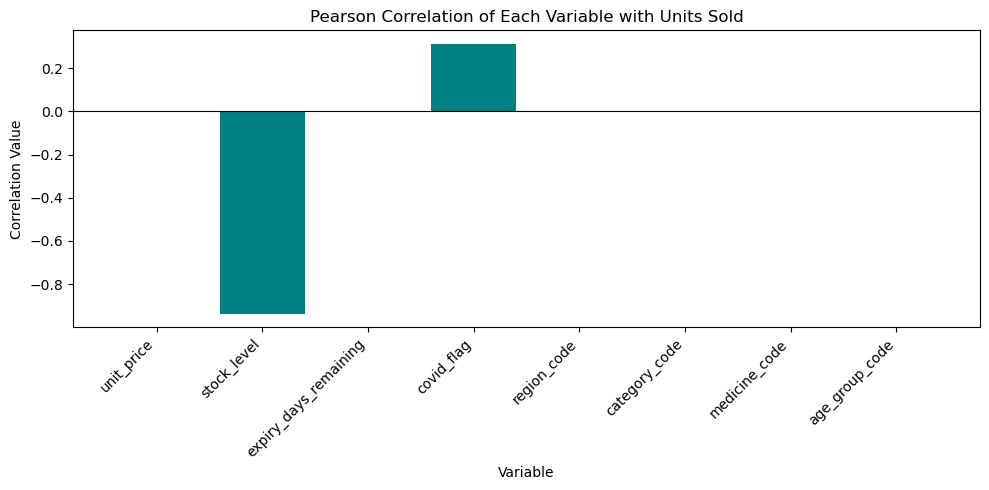

In [43]:
# bar chart to visualize correlation of each variable with units_sold
target_col = "units_sold"

# drop the target itself from comparison
compare_cols = [c for c in corr_cols if c != target_col]

pearson_values = [pearson_corr.loc[target_col, c] for c in compare_cols]

plt.figure(figsize=(10, 5))
plt.bar(compare_cols, pearson_values, color="teal")
plt.axhline(0, color="black", linewidth=0.8)   # zero reference line
plt.title("Pearson Correlation of Each Variable with Units Sold")
plt.xlabel("Variable")
plt.ylabel("Correlation Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

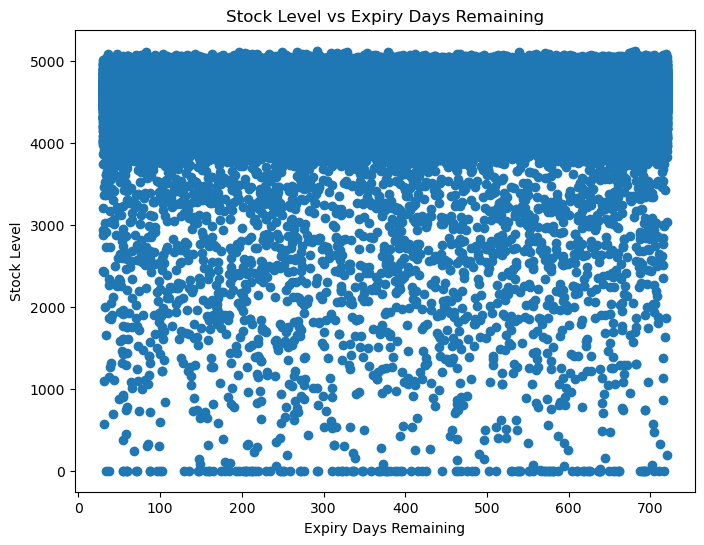

In [44]:
# scatterplot to visually check linear vs non-linear relationship
# example: stock_level vs expiry_days_remaining
plt.figure(figsize=(8, 6))
plt.scatter(df["expiry_days_remaining"], df["stock_level"])
plt.title("Stock Level vs Expiry Days Remaining")
plt.xlabel("Expiry Days Remaining")
plt.ylabel("Stock Level")
plt.show()

In [45]:

# Multicollinearity impact on models:
# 1. When two independent variables are highly correlated with each other,
#    it becomes hard for linear regression to estimate individual effect
#    of each variable on the target.
# 2. It can make model coefficients unstable and difficult to interpret.
# 3. It does not reduce prediction accuracy much, but reduces
#    interpretability of the model.
# 4. Tree based models (Random Forest, XGBoost) are less affected by
#    multicollinearity compared to linear regression.
#
# Mitigation strategies for multicollinearity:
# 1. Remove one of the two highly correlated variables.
# 2. Combine correlated variables into a single feature (feature engineering).
# 3. Use dimensionality reduction techniques like PCA.
# 4. Use regularization methods like Ridge or Lasso regression.

